In [6]:
import pandas as pd
from datetime import date, timedelta

import random
import geopandas as gpd
import numpy as np
import missingno

import sys

sys.path.insert(0, "../../Modules")

from utils import *

enc = 'utf-8'
dec = 'greek8'
pd.options.display.max_columns = None
random.seed(0)

In [7]:
NUTS0 = 'GR'

In [8]:
gr_grid = pd.read_csv(f'../data/{NUTS0}_Timeline_Biweekly_2010_filled.csv', encoding = enc)
gr_grid.head()

,x,y,cell_code,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,LAU1_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,month,year,indices_image_date,indices_lat,indices_lon,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_image_date,lst_lat,lst_lon,lst_day,lst_night,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week,acc_rainfall_2week
0,24.234167,41.115379,BV416,2010-01-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δοξατου,2.0,2.0,2.0,1,2010,2009-12-07,41.113645,24.234301,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,41.113645,24.234301,14329.0,13970.0,41.113645,24.234301,14100.142857,13790.625,14258.714286,13679.900000,14497.133333,13861.076923,14822.600000,14097.200000,2010-01-01,41.150188,24.250111,0.008292,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.008292,0.008292
1,24.234167,41.115379,BV416,2010-01-16,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δοξατου,2.0,2.0,2.0,1,2010,2009-12-07,41.113645,24.234301,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-16,41.113645,24.234301,14275.0,13867.0,41.113645,24.234301,14100.142857,13790.625,14258.714286,13679.900000,14497.133333,13861.076923,14822.600000,14097.200000,2010-01-16,41.150188,24.250111,16.971166,2010-01-09,2010-01-02,2010-01-09,2010-01-02,10.928824,16.037531
2,24.150728,41.088494,BY409,2010-01-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δοξατου,2.0,2.0,2.0,1,2010,2009-12-07,41.086695,24.148961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,41.086695,24.148961,14262.0,14027.0,41.086695,24.148961,14082.833333,13810.000,14150.750000,13741.142857,14520.466667,13852.230769,14848.470588,14065.583333,2010-01-01,41.050188,24.150110,0.037508,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.037508,0.037508
3,24.150728,41.088494,BY409,2010-01-16,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δοξατου,2.0,2.0,2.0,1,2010,2009-12-07,41.086695,24.148961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-16,41.086695,24.148961,14263.0,13872.0,41.086695,24.148961,14082.833333,13810.000,14150.750000,13741.142857,14520.466667,13852.230769,14848.470588,14065.583333,2010-01-16,41.050188,24.150110,19.008459,2010-01-09,2010-01-02,2010-01-09,2010-01-02,10.404103,16.001932
4,24.210173,41.061377,CB414,2010-01-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δοξατου,2.0,2.0,2.0,1,2010,2009-12-07,41.059746,24.211843,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,41.059746,24.211843,14170.0,13962.0,41.059746,24.211843,13981.333333,13784.250,14052.000000,13762.800000,14492.200000,13856.600000,14922.933333,14090.545455,2010-01-01,41.050188,24.250111,0.049862,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.049862,0.049862


In [11]:
gr_grid['dt_placement'] = pd.to_datetime(gr_grid['dt_placement'])
gr_grid['indices_image_date'] = pd.to_datetime(gr_grid['indices_image_date'])
gr_grid['indices_image_date.1'] = pd.to_datetime(gr_grid['indices_image_date.1'])
gr_grid['lst_image_date'] = pd.to_datetime(gr_grid['lst_image_date'])
gr_grid['dt_placement_minus_7'] = pd.to_datetime(gr_grid['dt_placement_minus_7'])
gr_grid['dt_placement_minus_7_avail'] = pd.to_datetime(gr_grid['dt_placement_minus_7_avail'])
gr_grid['dt_placement_minus_14'] = pd.to_datetime(gr_grid['dt_placement_minus_14'])
gr_grid['dt_placement_minus_14_avail'] = pd.to_datetime(gr_grid['dt_placement_minus_14_avail'])

In [13]:
gr_grid['indices_diff'] = (gr_grid['dt_placement'] - gr_grid['indices_image_date']).dt.days
gr_grid['indices_diff.1'] = (gr_grid['dt_placement'] - gr_grid['indices_image_date.1']).dt.days
gr_grid['lst_diff'] = (gr_grid['dt_placement'] - gr_grid['lst_image_date']).dt.days

gr_grid['rain_minus_7_diff'] = (gr_grid['dt_placement_minus_7'] - gr_grid['dt_placement_minus_7_avail']).dt.days
gr_grid['rain_minus_14_diff'] = (gr_grid['dt_placement_minus_14'] - gr_grid['dt_placement_minus_14_avail']).dt.days

In [14]:
gr_grid

,x,y,cell_code,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,LAU1_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,month,year,indices_image_date,indices_lat,indices_lon,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_image_date,lst_lat,lst_lon,lst_day,lst_night,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week,acc_rainfall_2week,indices_diff,indices_diff.1,lst_diff,rain_minus_7_diff,rain_minus_14_diff
0,24.234167,41.115379,BV416,2010-01-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δοξατου,2.0,2.0,2.0,1,2010,2009-12-07,41.113645,24.234301,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,41.113645,24.234301,14329.0,13970.0,41.113645,24.234301,14100.142857,13790.625,14258.714286,13679.900000,14497.133333,13861.076923,14822.600000,14097.200000,2010-01-01,41.150188,24.250111,0.008292,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.008292,0.008292,25.0,0.0,0.0,-356.0,-363.0
1,24.234167,41.115379,BV416,2010-01-16,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δοξατου,2.0,2.0,2.0,1,2010,2009-12-07,41.113645,24.234301,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-16,41.113645,24.234301,14275.0,13867.0,41.113645,24.234301,14100.142857,13790.625,14258.714286,13679.900000,14497.133333,13861.076923,14822.600000,14097.200000,2010-01-16,41.150188,24.250111,16.971166,2010-01-09,2010-01-02,2010-01-09,2010-01-02,10.928824,16.037531,40.0,0.0,0.0,0.0,0.0
2,24.150728,41.088494,BY409,2010-01-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δοξατου,2.0,2.0,2.0,1,2010,2009-12-07,41.086695,24.148961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,41.086695,24.148961,14262.0,14027.0,41.086695,24.148961,14082.833333,13810.000,14150.750000,13741.142857,14520.466667,13852.230769,14848.470588,14065.583333,2010-01-01,41.050188,24.150110,0.037508,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.037508,0.037508,25.0,0.0,0.0,-356.0,-363.0
3,24.150728,41.088494,BY409,2010-01-16,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δοξατου,2.0,2.0,2.0,1,2010,2009-12-07,41.086695,24.148961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-16,41.086695,24.148961,14263.0,13872.0,41.086695,24.148961,14082.833333,13810.000,14150.750000,13741.142857,14520.466667,13852.230769,14848.470588,14065.583333,2010-01-16,41.050188,24.150110,19.008459,2010-01-09,2010-01-02,2010-01-09,2010-01-02,10.404103,16.001932,40.0,0.0,0.0,0.0,0.0
4,24.210173,41.061377,CB414,2010-01-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δοξατου,2.0,2.0,2.0,1,2010,2009-12-07,41.059746,24.211843,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-01-01,41.059746,24.211843,14170.0,13962.0,41.059746,24.211843,13981.333333,13784.250,14052.000000,13762.800000,14492.200000,13856.600000,14922.933333,14090.545455,2010-01-01,41.050188,24.250111,0.049862,2009-12-25,2009-12-18,2010-12-16,2010-12-16,0.049862,0.049862,25.0,0.0,0.0,-356.0,-363.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63427,22.733595,38.558939,MS286,2010-12-16,EL6,κεντρικη ελλαδα,EL64,στερεα ελλαδα,EL644,αμφικλειας ελατειας,3.0,3.0,1.0,12,2010,2010-12-10,38.557938,22.734114,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-12-16,38.557938,22.734114,NaN,NaN,38.557938,22.734114,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-12-16,38.550176,22.750104,0.000000,2010-12-09,2010-12-02,2010-12-09,2010-12-02,0.000000,0.000000,6.0,0.0,0.0,0.0,0.0
63428,22.743656,38.640151,MJ287,2010-12-01,EL6,κεντρικη ελλαδα,EL64,στερ

In [17]:
print(gr_grid.indices_diff.max())
print(gr_grid.indices_diff.min())
print(gr_grid.indices_diff.mean())
print(gr_grid.indices_diff.std())

46.0
-27.0
10.430681276798476
11.06207404540611


In [20]:
print(gr_grid['indices_diff.1'].max())
print(gr_grid['indices_diff.1'].min())
print(gr_grid['indices_diff.1'].mean())
print(gr_grid['indices_diff.1'].std())

0.0
-349.0
-3.218599721589471
33.3608981319545


In [21]:
print(gr_grid.lst_diff.max())
print(gr_grid.lst_diff.min())
print(gr_grid.lst_diff.mean())
print(gr_grid.lst_diff.std())

0.0
0.0
0.0
0.0


In [22]:
print(gr_grid.rain_minus_7_diff.max())
print(gr_grid.rain_minus_7_diff.min())
print(gr_grid.rain_minus_7_diff.mean())
print(gr_grid.rain_minus_7_diff.std())

0.0
-356.0
-17.978154264743104
77.65263652753794


In [23]:
print(gr_grid.rain_minus_14_diff.max())
print(gr_grid.rain_minus_14_diff.min())
print(gr_grid.rain_minus_14_diff.mean())
print(gr_grid.rain_minus_14_diff.std())

0.0
-363.0
-18.33437737281701
79.19083365287452


<AxesSubplot:>

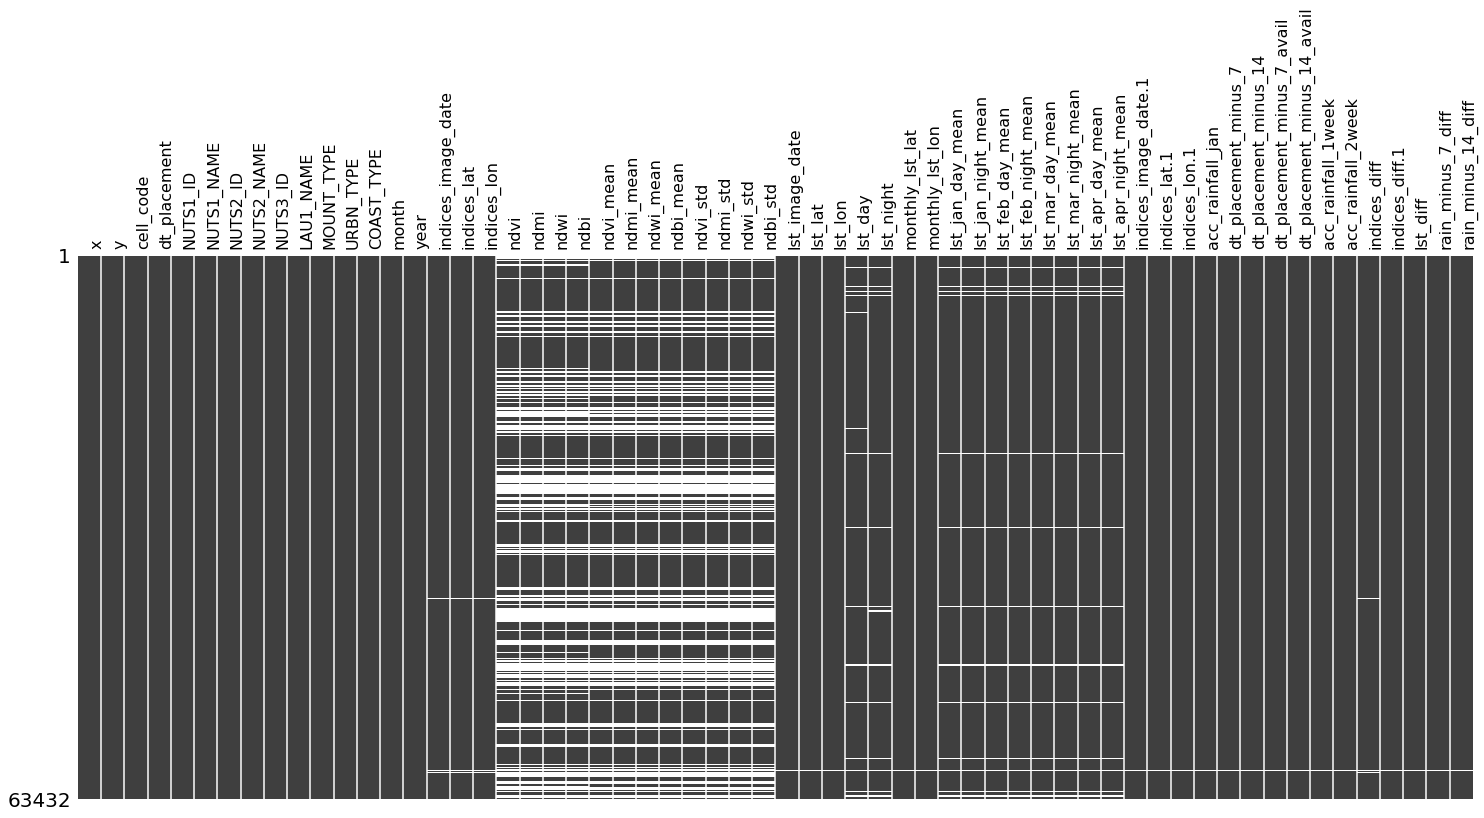

In [15]:
missingno.matrix(gr_grid, labels=True, label_rotation=90, sparkline=False)

In [10]:
describe_dataframe(gr_grid)

,Column,Missing
0,x,0.0000
1,y,0.0000
2,cell_code,0.0000
3,dt_placement,0.0000
4,NUTS1_ID,0.0000
5,NUTS1_NAME,0.0000
6,NUTS2_ID,0.0000
7,NUTS2_NAME,0.0000
8,NUTS3_ID,0.0000
9,LAU1_NAME,0.0000
